# 03 — WESAD All-Subject Baseline + Subject-Wise Validation

This notebook expands the S2 proof-of-concept to **all available WESAD subjects**.

Main goals:
1. Load all synchronized WESAD `.pkl` files.
2. Extract the same 60-second window features for every subject.
3. Combine all subjects into one processed dataset.
4. Train baseline ML models.
5. Evaluate with **leave-one-subject-out (LOSO)** validation.
6. Save results, figures, and processed feature tables.

### Methodological purpose

The single-subject analysis establishes initial feasibility, while LOSO validation evaluates whether learned relationships generalize to unseen participants. The resulting benchmarks provide a more rigorous basis for evaluating subsequent deep-learning and latent-representation models.


In [ ]:
# ============================================================
# STEP 1. Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ============================================================
# STEP 2. Import libraries
# ============================================================
import os
import glob
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut, GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)


In [ ]:
# ============================================================
# STEP 3. Define project paths
# Root directory for the analysis project.
# ============================================================
PROJECT_ROOT = "/content/drive/MyDrive/Apple_Hidden_Wellness_AI"

RAW_WESAD_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "WESAD", "WESAD")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("RAW_WESAD_DIR:", RAW_WESAD_DIR)
print("Exists:", os.path.exists(RAW_WESAD_DIR))


RAW_WESAD_DIR: /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD
Exists: True


In [ ]:
# ============================================================
# STEP 4. Find all subject .pkl files
# ============================================================
pkl_files = sorted(glob.glob(os.path.join(RAW_WESAD_DIR, "S*", "S*.pkl")))

print("Number of subject pkl files:", len(pkl_files))
for f in pkl_files:
    print(f)

if len(pkl_files) == 0:
    raise FileNotFoundError("No .pkl files found. Check RAW_WESAD_DIR path.")


Number of subject pkl files: 15
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S10/S10.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S11/S11.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S13/S13.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S14/S14.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S15/S15.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S16/S16.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S17/S17.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S2/S2.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S3/S3.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S4/S4.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S5/S5.pkl
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/raw/WESAD/WESAD/S6/S6.pkl
/conte

## Label definition

WESAD protocol labels:
- `1 = baseline`
- `2 = stress`
- `3 = amusement`
- `4 = meditation`

For this baseline notebook:
- `0 = non-stress / baseline`
- `1 = stress`

We ignore amusement and meditation in the first all-subject baseline model to keep the preliminary analysis clean.


In [ ]:
# ============================================================
# STEP 5. Feature extraction function
# ============================================================

def safe_skew(x):
    x = np.asarray(x)
    if len(x) < 3 or np.std(x) == 0:
        return 0.0
    return pd.Series(x).skew()

def extract_window_features_from_pkl(pkl_path, window_sec=60, step_sec=30, fs=700, min_majority=0.80):
    """
    Load one WESAD subject .pkl file and extract window-level features.

    Returns one row per valid baseline/stress window.
    """
    subject_id = os.path.basename(pkl_path).replace(".pkl", "")

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    chest = data["signal"]["chest"]
    labels = np.asarray(data["label"]).flatten()

    ecg = np.asarray(chest["ECG"]).flatten()
    eda = np.asarray(chest["EDA"]).flatten()
    temp_key = "Temp" if "Temp" in chest else "TEMP"
    temp = np.asarray(chest[temp_key]).flatten()
    resp = np.asarray(chest["Resp"]).flatten()

    acc = np.asarray(chest["ACC"])
    if acc.ndim == 2 and acc.shape[1] == 3:
        acc_mag = np.sqrt(np.sum(acc**2, axis=1))
    else:
        acc_mag = np.asarray(acc).flatten()

    min_len = min(len(ecg), len(eda), len(temp), len(resp), len(acc_mag), len(labels))
    ecg = ecg[:min_len]
    eda = eda[:min_len]
    temp = temp[:min_len]
    resp = resp[:min_len]
    acc_mag = acc_mag[:min_len]
    labels = labels[:min_len]

    window_size = int(window_sec * fs)
    step_size = int(step_sec * fs)

    rows = []

    for start in range(0, min_len - window_size, step_size):
        end = start + window_size
        y_window = labels[start:end]

        values, counts = np.unique(y_window, return_counts=True)
        majority_label = values[np.argmax(counts)]
        majority_fraction = np.max(counts) / len(y_window)

        if majority_label not in [1, 2]:
            continue
        if majority_fraction < min_majority:
            continue

        y = 1 if majority_label == 2 else 0

        signals = {
            "ECG": ecg[start:end],
            "EDA": eda[start:end],
            "TEMP": temp[start:end],
            "RESP": resp[start:end],
            "ACC": acc_mag[start:end]
        }

        row = {
            "subject": subject_id,
            "start_sec": start / fs,
            "end_sec": end / fs,
            "label": y,
            "majority_fraction": majority_fraction
        }

        for name, sig in signals.items():
            row[f"{name}_mean"] = np.mean(sig)
            row[f"{name}_std"] = np.std(sig)
            row[f"{name}_min"] = np.min(sig)
            row[f"{name}_max"] = np.max(sig)
            row[f"{name}_median"] = np.median(sig)
            row[f"{name}_iqr"] = np.percentile(sig, 75) - np.percentile(sig, 25)
            row[f"{name}_skew"] = safe_skew(sig)

            idx = np.linspace(0, len(sig) - 1, min(200, len(sig))).astype(int)
            x_small = idx / fs
            y_small = sig[idx]
            try:
                row[f"{name}_slope"] = np.polyfit(x_small, y_small, 1)[0]
            except Exception:
                row[f"{name}_slope"] = 0.0

        rows.append(row)

    return pd.DataFrame(rows)


In [ ]:
# ============================================================
# STEP 6. Extract features for all subjects
# This may take a few minutes.
# ============================================================
all_dfs = []

for pkl_path in pkl_files:
    subject_id = os.path.basename(pkl_path).replace(".pkl", "")
    print("Processing:", subject_id)
    try:
        df_sub = extract_window_features_from_pkl(
            pkl_path,
            window_sec=60,
            step_sec=30,
            fs=700,
            min_majority=0.80
        )
        print("  windows:", df_sub.shape[0])
        all_dfs.append(df_sub)
    except Exception as e:
        print("  ERROR:", e)

df_all = pd.concat(all_dfs, ignore_index=True)

print("\nCombined shape:", df_all.shape)
display(df_all.head())
print("\nSubjects:", sorted(df_all["subject"].unique()))
print("\nLabel counts:")
print(df_all["label"].value_counts())
print("\nWindows per subject:")
display(df_all.groupby(["subject", "label"]).size().unstack(fill_value=0))


Processing: S10
  windows: 60
Processing: S11
  windows: 59
Processing: S13
  windows: 59
Processing: S14
  windows: 59
Processing: S15
  windows: 60
Processing: S16
  windows: 61
Processing: S17
  windows: 61
Processing: S2
  windows: 56
Processing: S3
  windows: 57
Processing: S4
  windows: 57
Processing: S5
  windows: 59
Processing: S6
  windows: 59
Processing: S7
  windows: 59
Processing: S8
  windows: 59
Processing: S9
  windows: 58

Combined shape: (883, 45)


,subject,start_sec,end_sec,label,majority_fraction,ECG_mean,ECG_std,ECG_min,ECG_max,ECG_median,ECG_iqr,ECG_skew,ECG_slope,EDA_mean,EDA_std,EDA_min,EDA_max,EDA_median,EDA_iqr,EDA_skew,EDA_slope,TEMP_mean,TEMP_std,TEMP_min,TEMP_max,TEMP_median,TEMP_iqr,TEMP_skew,TEMP_slope,RESP_mean,RESP_std,RESP_min,RESP_max,RESP_median,RESP_iqr,RESP_skew,RESP_slope,ACC_mean,ACC_std,ACC_min,ACC_max,ACC_median,ACC_iqr,ACC_skew,ACC_slope
0,S10,90.0,150.0,0,0.952381,0.001702,0.136454,-0.667923,0.821457,0.030167,0.095490,-0.036454,0.000685,0.739102,0.013610,0.563812,0.863266,0.736237,0.016785,1.401023,0.000185,33.923397,0.038611,33.805054,34.101654,33.923553,0.054779,-0.098886,0.001688,-0.048631,3.203791,-8.285522,8.479309,-0.468445,4.975891,0.101513,0.008874,0.912323,0.006273,0.842257,1.037667,0.912158,0.004774,4.843151,0.000023
1,S10,120.0,180.0,0,1.000000,0.001372,0.151259,-0.667923,0.838211,0.020828,0.125427,0.297378,-0.000076,0.744245,0.013809,0.594711,0.881195,0.741577,0.016022,1.502864,0.000151,33.988762,0.052775,33.855164,34.196198,33.981354,0.082153,0.220322,0.002808,0.002573,3.421302,-12.843323,11.723328,-0.321960,4.373169,0.061105,0.000499,0.915668,0.008497,0.842257,1.037667,0.915388,0.007760,2.360465,0.000139
2,S10,150.0,210.0,0,1.000000,0.000920,0.159931,-0.664948,0.871902,0.003525,0.146084,0.367537,0.000923,0.747692,0.013591,0.453186,0.881195,0.745010,0.017166,1.358869,0.000039,34.068615,0.053360,33.911377,34.252716,34.072723,0.083801,-0.339466,0.002683,0.077553,3.250835,-12.843323,11.723328,-0.254822,3.677368,-0.012825,-0.000166,0.918700,0.006092,0.847633,1.033307,0.918762,0.005144,1.356411,0.000015
3,S10,180.0,240.0,0,1.000000,0.001438,0.159889,-0.700928,0.871902,-0.000847,0.145260,0.346422,-0.000041,0.749359,0.013476,0.453186,0.851440,0.746536,0.016403,1.337434,0.000127,34.134739,0.039046,34.011810,34.303101,34.135193,0.059448,-0.243038,0.001722,0.103903,1.961128,-3.910828,4.554749,-0.465393,3.343201,0.443304,-0.000923,0.918624,0.004006,0.900466,0.935207,0.918658,0.005014,-0.005060,-0.000038
4,S10,210.0,270.0,0,1.000000,0.001176,0.160889,-0.700928,0.827225,-0.003891,0.147675,0.286364,0.000066,0.751742,0.013415,0.595474,0.860977,0.748444,0.016403,1.557622,0.000126,34.185028,0.038804,34.054443,34.370392,34.183990,0.051880,-0.056315,0.001554,0.065258,1.904876,-3.910828,4.191589,-0.443268,3.218079,0.400386,0.000533,0.918779,0.004095,0.900466,0.937938,0.918776,0.005033,0.041166,-0.000012



Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

Label counts:
label
0    570
1    313
Name: count, dtype: int64

Windows per subject:


label,0,1
subject,,
S10,38,22
S11,38,21
S13,38,21
S14,38,21
S15,38,22
S16,39,22
S17,38,23
S2,37,19
S3,37,20


In [ ]:
# ============================================================
# STEP 7. Save all-subject feature dataset
# ============================================================
features_path = os.path.join(PROCESSED_DIR, "wesad_all_subjects_window_features.csv")
df_all.to_csv(features_path, index=False)
print("Saved:", features_path)


Saved: /content/drive/MyDrive/Apple_Hidden_Wellness_AI/data/processed/wesad_all_subjects_window_features.csv


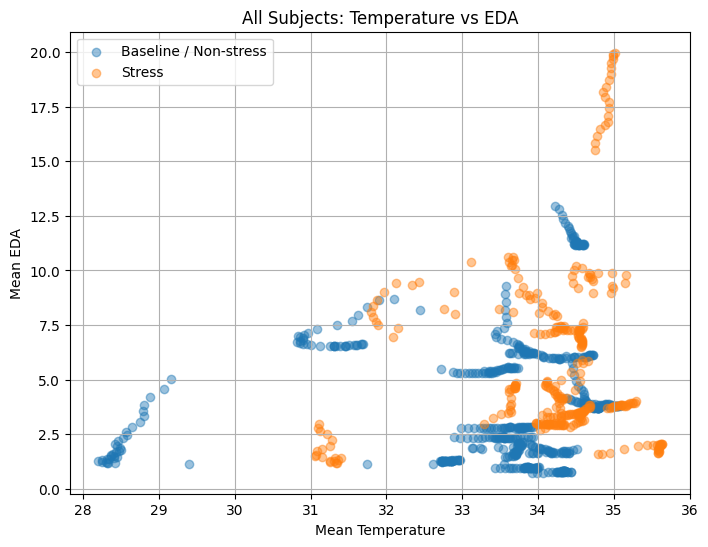

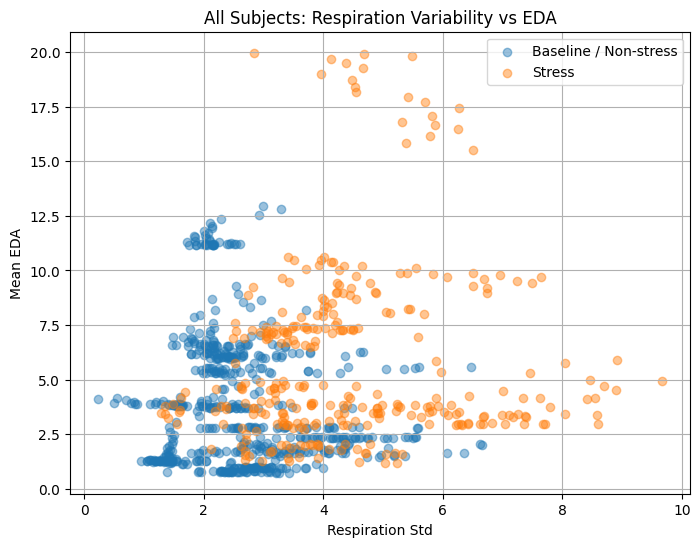

In [ ]:
# ============================================================
# STEP 8. Basic visualization: class separation
# ============================================================
label_names = {0: "Baseline / Non-stress", 1: "Stress"}

plt.figure(figsize=(8, 6))
for label in sorted(df_all["label"].unique()):
    subset = df_all[df_all["label"] == label]
    plt.scatter(subset["TEMP_mean"], subset["EDA_mean"], alpha=0.45, label=label_names[label])

plt.xlabel("Mean Temperature")
plt.ylabel("Mean EDA")
plt.title("All Subjects: Temperature vs EDA")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
for label in sorted(df_all["label"].unique()):
    subset = df_all[df_all["label"] == label]
    plt.scatter(subset["RESP_std"], subset["EDA_mean"], alpha=0.45, label=label_names[label])

plt.xlabel("Respiration Std")
plt.ylabel("Mean EDA")
plt.title("All Subjects: Respiration Variability vs EDA")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ============================================================
# STEP 9. Prepare model inputs
# ============================================================
metadata_cols = ["subject", "start_sec", "end_sec", "label", "majority_fraction"]

feature_cols = [c for c in df_all.columns if c not in metadata_cols]

X = df_all[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df_all["label"].astype(int)
groups = df_all["subject"]

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())


Number of features: 40
X shape: (883, 40)
y distribution:
label
0    570
1    313
Name: count, dtype: int64


# Part A — Random split baseline

This split is **not the final evaluation**, because windows from the same subject may appear in both training and testing.

It is included only as a quick sanity check.


In [ ]:
# ============================================================
# STEP 10. Random split sanity-check baseline
# ============================================================
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

random_results = []

for name, model in models.items():
    model.fit(X_train_rand, y_train_rand)
    pred = model.predict(X_test_rand)

    try:
        prob = model.predict_proba(X_test_rand)[:, 1]
        auc = roc_auc_score(y_test_rand, prob)
    except Exception:
        auc = np.nan

    random_results.append({
        "validation": "random_window_split",
        "model": name,
        "accuracy": accuracy_score(y_test_rand, pred),
        "f1": f1_score(y_test_rand, pred),
        "roc_auc": auc
    })

random_results_df = pd.DataFrame(random_results)
display(random_results_df)


,validation,model,accuracy,f1,roc_auc
0,random_window_split,Logistic Regression,0.939623,0.913978,0.983887
1,random_window_split,SVM,0.984906,0.978495,0.999627
2,random_window_split,Random Forest,0.988679,0.984127,0.999751


# Part B — Leave-One-Subject-Out Validation

LOSO is used as the primary evaluation framework because it measures subject-independent generalization.

Each fold holds out one subject for testing and trains on all other subjects. This tests whether the model generalizes to an unseen person.


In [ ]:
# ============================================================
# STEP 11. Leave-One-Subject-Out validation
# ============================================================
logo = LeaveOneGroupOut()

loso_results = []
all_true = {name: [] for name in models.keys()}
all_pred = {name: [] for name in models.keys()}
all_prob = {name: [] for name in models.keys()}

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups=groups), start=1):
    test_subject = groups.iloc[test_idx].iloc[0]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print(f"Fold {fold_idx}: Test subject = {test_subject}, Test windows = {len(test_idx)}")

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        try:
            prob = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, prob) if len(np.unique(y_test)) > 1 else np.nan
        except Exception:
            prob = np.full(len(y_test), np.nan)
            auc = np.nan

        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, zero_division=0)

        loso_results.append({
            "fold": fold_idx,
            "test_subject": test_subject,
            "model": name,
            "n_test_windows": len(test_idx),
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc
        })

        all_true[name].extend(list(y_test))
        all_pred[name].extend(list(pred))
        all_prob[name].extend(list(prob))

loso_results_df = pd.DataFrame(loso_results)
display(loso_results_df.head())


Fold 1: Test subject = S10, Test windows = 60
Fold 2: Test subject = S11, Test windows = 59
Fold 3: Test subject = S13, Test windows = 59
Fold 4: Test subject = S14, Test windows = 59
Fold 5: Test subject = S15, Test windows = 60
Fold 6: Test subject = S16, Test windows = 61
Fold 7: Test subject = S17, Test windows = 61
Fold 8: Test subject = S2, Test windows = 56
Fold 9: Test subject = S3, Test windows = 57
Fold 10: Test subject = S4, Test windows = 57
Fold 11: Test subject = S5, Test windows = 59
Fold 12: Test subject = S6, Test windows = 59
Fold 13: Test subject = S7, Test windows = 59
Fold 14: Test subject = S8, Test windows = 59
Fold 15: Test subject = S9, Test windows = 58


,fold,test_subject,model,n_test_windows,accuracy,f1,roc_auc
0,1,S10,Logistic Regression,60,0.366667,0.536585,0.944976
1,1,S10,SVM,60,0.366667,0.536585,0.972488
2,1,S10,Random Forest,60,0.750000,0.482759,1.000000
3,2,S11,Logistic Regression,59,0.983051,0.975610,1.000000
4,2,S11,SVM,59,1.000000,1.000000,1.000000


In [ ]:
# ============================================================
# STEP 12. Summarize LOSO results
# ============================================================
summary_df = (
    loso_results_df
    .groupby("model")[["accuracy", "f1", "roc_auc"]]
    .agg(["mean", "std"])
)

display(summary_df)

summary_flat = loso_results_df.groupby("model").agg(
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
    roc_auc_mean=("roc_auc", "mean"),
    roc_auc_std=("roc_auc", "std")
).reset_index()

display(summary_flat)


accuracy                  f1             roc_auc  \
                         mean       std      mean       std      mean   
model                                                                   
Logistic Regression  0.814880  0.213165  0.767919  0.224068  0.967876   
Random Forest        0.920850  0.101148  0.851835  0.211569  0.981615   
SVM                  0.858116  0.186172  0.772703  0.312350  0.913084   

                               
                          std  
model                          
Logistic Regression  0.043892  
Random Forest        0.041197  
SVM                  0.244230

,model,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.814880,0.213165,0.767919,0.224068,0.967876,0.043892
1,Random Forest,0.920850,0.101148,0.851835,0.211569,0.981615,0.041197
2,SVM,0.858116,0.186172,0.772703,0.312350,0.913084,0.244230


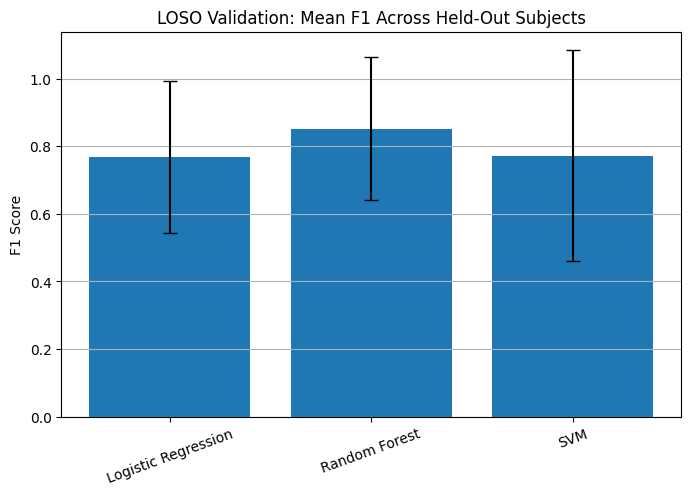

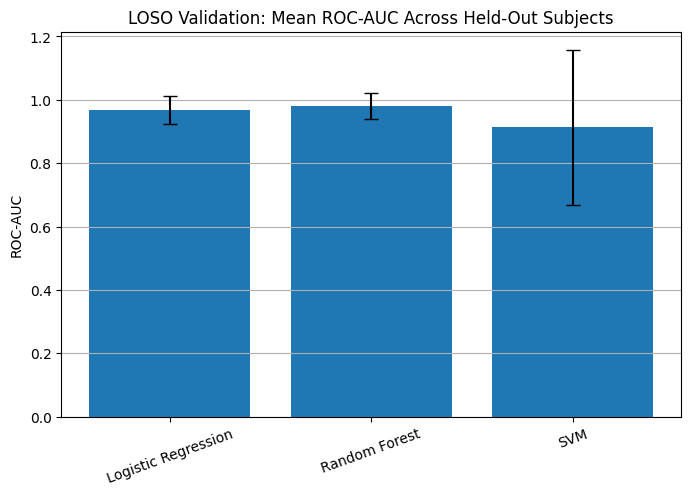

In [ ]:
# ============================================================
# STEP 13. Plot LOSO performance by model
# ============================================================
plt.figure(figsize=(8, 5))
plt.bar(summary_flat["model"], summary_flat["f1_mean"], yerr=summary_flat["f1_std"], capsize=5)
plt.ylabel("F1 Score")
plt.title("LOSO Validation: Mean F1 Across Held-Out Subjects")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_flat["model"], summary_flat["roc_auc_mean"], yerr=summary_flat["roc_auc_std"], capsize=5)
plt.ylabel("ROC-AUC")
plt.title("LOSO Validation: Mean ROC-AUC Across Held-Out Subjects")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()


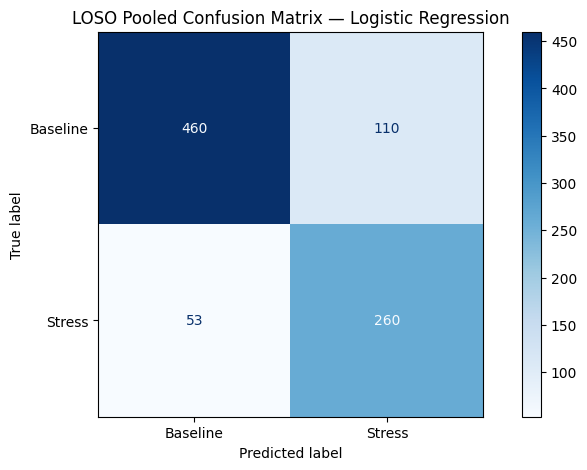


Logistic Regression
              precision    recall  f1-score   support

    Baseline       0.90      0.81      0.85       570
      Stress       0.70      0.83      0.76       313

    accuracy                           0.82       883
   macro avg       0.80      0.82      0.81       883
weighted avg       0.83      0.82      0.82       883



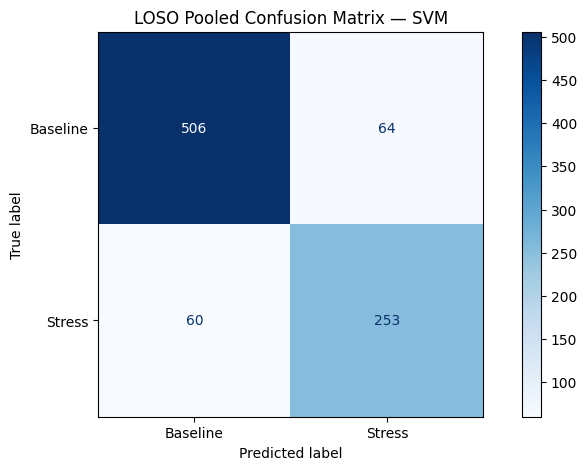


SVM
              precision    recall  f1-score   support

    Baseline       0.89      0.89      0.89       570
      Stress       0.80      0.81      0.80       313

    accuracy                           0.86       883
   macro avg       0.85      0.85      0.85       883
weighted avg       0.86      0.86      0.86       883



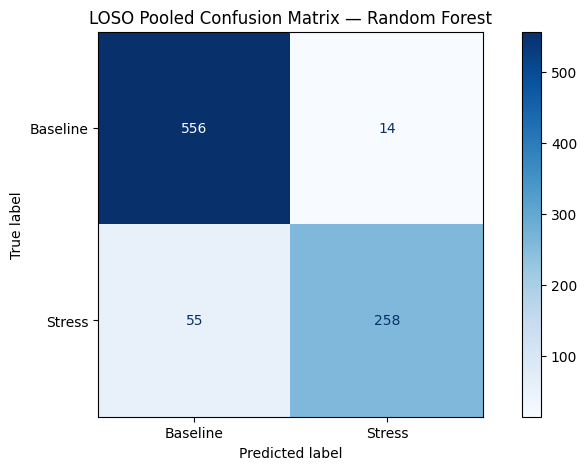


Random Forest
              precision    recall  f1-score   support

    Baseline       0.91      0.98      0.94       570
      Stress       0.95      0.82      0.88       313

    accuracy                           0.92       883
   macro avg       0.93      0.90      0.91       883
weighted avg       0.92      0.92      0.92       883



In [ ]:
# ============================================================
# STEP 14. Overall confusion matrices from LOSO pooled predictions
# ============================================================
for name in models.keys():
    y_true_all = np.array(all_true[name])
    y_pred_all = np.array(all_pred[name])

    ConfusionMatrixDisplay.from_predictions(
        y_true_all,
        y_pred_all,
        display_labels=["Baseline", "Stress"],
        cmap="Blues"
    )
    plt.title(f"LOSO Pooled Confusion Matrix — {name}")
    plt.show()

    print("\n", "="*60)
    print(name)
    print("="*60)
    print(classification_report(y_true_all, y_pred_all, target_names=["Baseline", "Stress"], zero_division=0))


,Feature,Importance
37,ACC_iqr,0.161191
33,ACC_std,0.123991
9,EDA_std,0.066655
25,RESP_std,0.058003
15,EDA_slope,0.052776
27,RESP_max,0.051063
13,EDA_iqr,0.041783
1,ECG_std,0.037833
30,RESP_skew,0.034430
34,ACC_min,0.030882


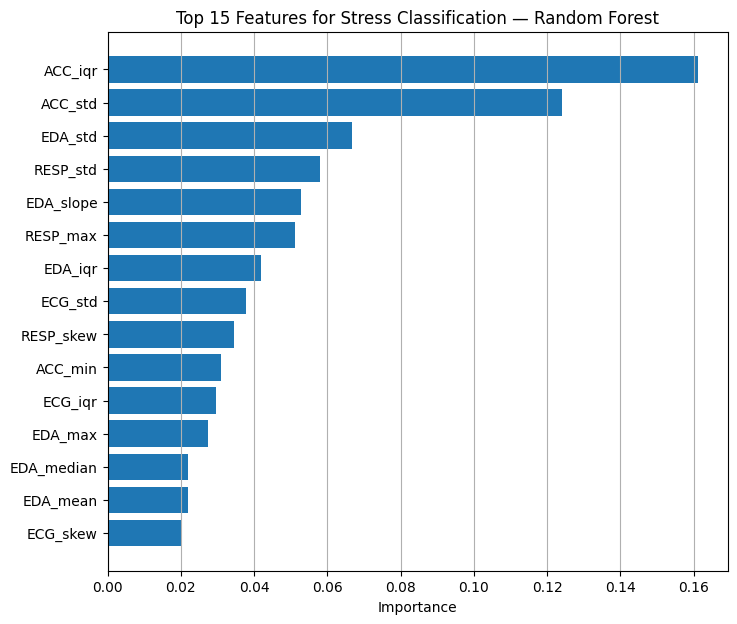

In [ ]:
# ============================================================
# STEP 15. Feature importance from Random Forest trained on all data
# This is descriptive, not a final causal interpretation.
# ============================================================
rf_all = RandomForestClassifier(n_estimators=500, random_state=42, class_weight="balanced")
rf_all.fit(X, y)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_all.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.head(20))

top_n = 15
top_imp = importance_df.head(top_n).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 7))
plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.xlabel("Importance")
plt.title(f"Top {top_n} Features for Stress Classification — Random Forest")
plt.grid(axis="x")
plt.show()


# Part C — Missing-Sensor Reconstruction Across All Subjects

This analysis evaluates cross-modal reconstruction by estimating `EDA_mean` after excluding all EDA-derived predictors.


Held-out test subjects: ['S10', 'S4', 'S6', 'S8']
EDA Reconstruction Across Held-Out Subjects
MAE: 5.13801750388286
RMSE: 6.684657661275262
R2: -5.237773029253608


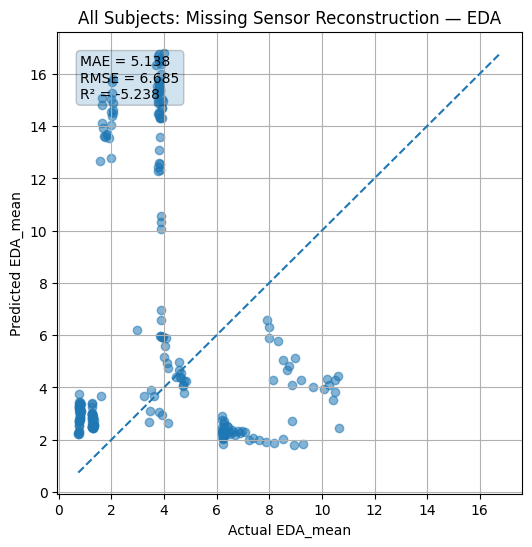

In [ ]:
# ============================================================
# STEP 16. Missing-sensor reconstruction: predict EDA_mean
# Subject-wise split for honest evaluation
# ============================================================
target_col = "EDA_mean"
reconstruction_feature_cols = [c for c in feature_cols if not c.startswith("EDA_")]

X_rec = df_all[reconstruction_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y_rec = df_all[target_col].astype(float)
groups_rec = df_all["subject"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_rec, y_rec, groups=groups_rec))

X_train_rec, X_test_rec = X_rec.iloc[train_idx], X_rec.iloc[test_idx]
y_train_rec, y_test_rec = y_rec.iloc[train_idx], y_rec.iloc[test_idx]
test_subjects = sorted(groups_rec.iloc[test_idx].unique())

print("Held-out test subjects:", test_subjects)

rec_model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", RandomForestRegressor(n_estimators=400, random_state=42))
])

rec_model.fit(X_train_rec, y_train_rec)
pred_rec = rec_model.predict(X_test_rec)

mae = mean_absolute_error(y_test_rec, pred_rec)
rmse = np.sqrt(mean_squared_error(y_test_rec, pred_rec))
r2 = r2_score(y_test_rec, pred_rec)

print("EDA Reconstruction Across Held-Out Subjects")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_rec, pred_rec, alpha=0.55)

min_val = min(y_test_rec.min(), pred_rec.min())
max_val = max(y_test_rec.max(), pred_rec.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual EDA_mean")
plt.ylabel("Predicted EDA_mean")
plt.title("All Subjects: Missing Sensor Reconstruction — EDA")

text = f"MAE = {mae:.3f}\nRMSE = {rmse:.3f}\nR² = {r2:.3f}"
plt.text(
    0.05, 0.95, text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.2)
)

plt.grid(True)
plt.show()


# Part D — Simple Early Detection Prototype

This is an early-warning baseline.

For each subject, we use features from the current window to predict the label of the **next window**.
With 60-second windows and 30-second step size, this is approximately a short-horizon early prediction task.

This analysis is limited to one-window-ahead prediction; longer forecast horizons are reserved for subsequent temporal-modeling experiments.


In [ ]:
# ============================================================
# STEP 17. Create next-window labels within each subject
# ============================================================
df_early = df_all.sort_values(["subject", "start_sec"]).copy()
df_early["future_label"] = df_early.groupby("subject")["label"].shift(-1)
df_early = df_early.dropna(subset=["future_label"]).copy()
df_early["future_label"] = df_early["future_label"].astype(int)

X_early = df_early[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y_early = df_early["future_label"]
groups_early = df_early["subject"]

print("Early dataset shape:", df_early.shape)
print(y_early.value_counts())


Early dataset shape: (868, 46)
future_label
0    555
1    313
Name: count, dtype: int64


,fold,test_subject,accuracy,f1,roc_auc,n_test_windows
0,1,S10,0.915254,0.871795,0.974201,59
1,2,S11,0.982759,0.975610,0.960746,58
2,3,S13,0.965517,0.950000,0.974260,58
3,4,S14,0.948276,0.930233,0.983912,58
4,5,S15,0.915254,0.878049,0.948403,59
5,6,S16,0.983333,0.976744,0.982057,60
6,7,S17,0.983333,0.977778,0.981786,60
7,8,S2,0.727273,0.400000,0.856725,55
8,9,S3,0.946429,0.926829,0.993056,56
9,10,S4,0.785714,0.571429,0.979861,56


Early Detection Summary:


,accuracy,f1,roc_auc
mean,0.912226,0.856487,0.964140
std,0.090263,0.175398,0.038185


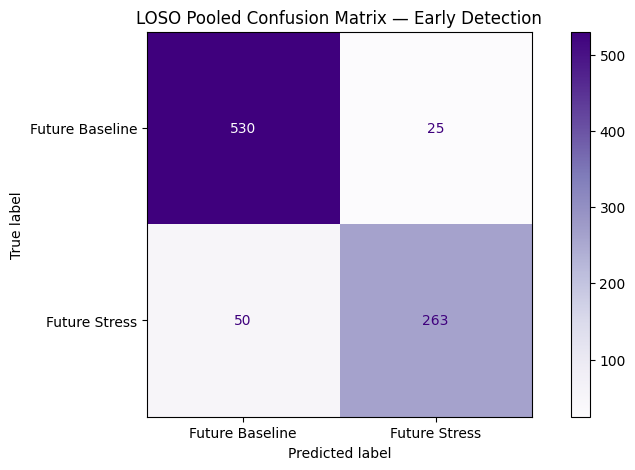

                 precision    recall  f1-score   support

Future Baseline       0.91      0.95      0.93       555
  Future Stress       0.91      0.84      0.88       313

       accuracy                           0.91       868
      macro avg       0.91      0.90      0.90       868
   weighted avg       0.91      0.91      0.91       868



In [ ]:
# ============================================================
# STEP 18. LOSO validation for early detection
# ============================================================
early_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")

early_results = []
early_true = []
early_pred = []
early_prob = []

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X_early, y_early, groups=groups_early), start=1):
    test_subject = groups_early.iloc[test_idx].iloc[0]

    X_train, X_test = X_early.iloc[train_idx], X_early.iloc[test_idx]
    y_train, y_test = y_early.iloc[train_idx], y_early.iloc[test_idx]

    early_model.fit(X_train, y_train)
    pred = early_model.predict(X_test)

    try:
        prob = early_model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, prob) if len(np.unique(y_test)) > 1 else np.nan
    except Exception:
        prob = np.full(len(y_test), np.nan)
        auc = np.nan

    early_results.append({
        "fold": fold_idx,
        "test_subject": test_subject,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": auc,
        "n_test_windows": len(test_idx)
    })

    early_true.extend(list(y_test))
    early_pred.extend(list(pred))
    early_prob.extend(list(prob))

early_results_df = pd.DataFrame(early_results)
display(early_results_df)

print("Early Detection Summary:")
display(early_results_df[["accuracy", "f1", "roc_auc"]].agg(["mean", "std"]))

ConfusionMatrixDisplay.from_predictions(
    early_true,
    early_pred,
    display_labels=["Future Baseline", "Future Stress"],
    cmap="Purples"
)
plt.title("LOSO Pooled Confusion Matrix — Early Detection")
plt.show()

print(classification_report(early_true, early_pred, target_names=["Future Baseline", "Future Stress"], zero_division=0))


In [ ]:
# ============================================================
# STEP 19. Save all results
# ============================================================
loso_results_path = os.path.join(RESULTS_DIR, "wesad_loso_classification_results.csv")
summary_results_path = os.path.join(RESULTS_DIR, "wesad_loso_summary_results.csv")
importance_path = os.path.join(RESULTS_DIR, "wesad_rf_feature_importance.csv")
early_results_path = os.path.join(RESULTS_DIR, "wesad_loso_early_detection_results.csv")
random_results_path = os.path.join(RESULTS_DIR, "wesad_random_split_baseline_results.csv")

loso_results_df.to_csv(loso_results_path, index=False)
summary_flat.to_csv(summary_results_path, index=False)
importance_df.to_csv(importance_path, index=False)
early_results_df.to_csv(early_results_path, index=False)
random_results_df.to_csv(random_results_path, index=False)

print("Saved:")
print(loso_results_path)
print(summary_results_path)
print(importance_path)
print(early_results_path)
print(random_results_path)


Saved:
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/results/wesad_loso_classification_results.csv
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/results/wesad_loso_summary_results.csv
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/results/wesad_rf_feature_importance.csv
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/results/wesad_loso_early_detection_results.csv
/content/drive/MyDrive/Apple_Hidden_Wellness_AI/results/wesad_random_split_baseline_results.csv


# Interpretation

The all-subject analysis provides three preliminary findings:

1. Multimodal physiological features can be extracted consistently across the available WESAD participants.
2. EDA-related information can be partially reconstructed from non-EDA modalities, providing an initial test of cross-modal recoverability.
3. Current-window physiological features contain information relevant to short-horizon prediction of subsequent stress states.

Random window splits are retained only as diagnostic baselines because they may include participant-specific information in both training and testing sets. LOSO results are therefore treated as the primary subject-independent benchmark for comparison with the deep-learning models developed in later notebooks.